         x        y        z facecolor  i  j  k
0 -39.4947  160.318  4.01684   #A9D0E4  0  1  2
1 -41.7517  160.311  4.77783   #AED3E6  0  3  1
2 -41.3307  160.309  5.96566   #B4D6E7  0  4  3
3 -41.7790  160.312  3.64150   #B8D8E9  0  5  4
4 -41.5541  160.314  2.62999   #BBD9EA  0  6  5
(2094, 7)

Cluster counts:
cluster
1    1008
0     566
2     520
Name: count, dtype: int64


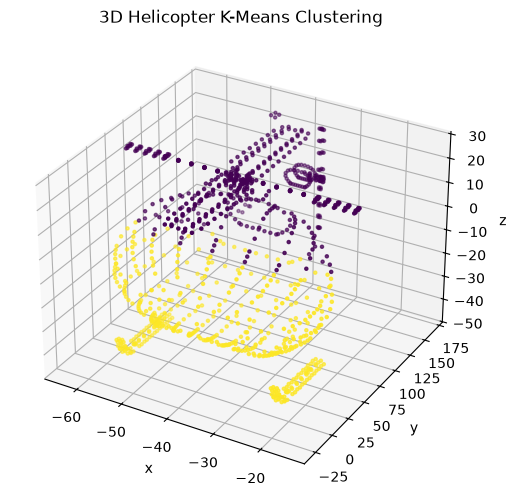


NLP clusters:
  facecolor  nlp_cluster
0   #A9D0E4            0
1   #AED3E6            0
2   #B4D6E7            0
3   #B8D8E9            0
4   #BBD9EA            0

Done! Saved as helicopter_clustered.csv


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5040/3508634245.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


In [1]:
# 1. Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Load dataset
df = pd.read_csv("3d-mesh-helicopter.csv")
print(df.head())
print(df.shape)

# 3. K-Means on numerical 3D data
num_cols = df.select_dtypes(include="number").columns

X = df[num_cols].fillna(0)
X = StandardScaler().fit_transform(X)

k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

print("\nCluster counts:")
print(df["cluster"].value_counts())

# 4. 3D visualization (first 3 numerical columns)
if len(num_cols) >= 3:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        df[num_cols[0]],
        df[num_cols[1]],
        df[num_cols[2]],
        c=df["cluster"],
        cmap="viridis",
        s=5
    )

    ax.set_xlabel(num_cols[0])
    ax.set_ylabel(num_cols[1])
    ax.set_zlabel(num_cols[2])
    plt.title("3D Helicopter K-Means Clustering")
    plt.show()

# 5. NLP (if a text column exists)
text_cols = df.select_dtypes(include="object").columns

if len(text_cols) > 0:
    text_col = text_cols[0]

    text = df[text_col].fillna("").astype(str)

    tfidf = TfidfVectorizer(stop_words="english")
    text_X = tfidf.fit_transform(text)

    nlp_model = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["nlp_cluster"] = nlp_model.fit_predict(text_X)

    print("\nNLP clusters:")
    print(df[[text_col, "nlp_cluster"]].head())

# 6. Save result
df.to_csv("helicopter_clustered.csv", index=False)
print("\nDone! Saved as helicopter_clustered.csv")